In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv(
    "twitter_training (1).csv",
    header=None
)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
print(df.shape)

df.info()

(74682, 4)
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [5]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [6]:
df.dropna(inplace=True)

df.isnull().sum()

Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

In [7]:
df["Sentiment"].value_counts()

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

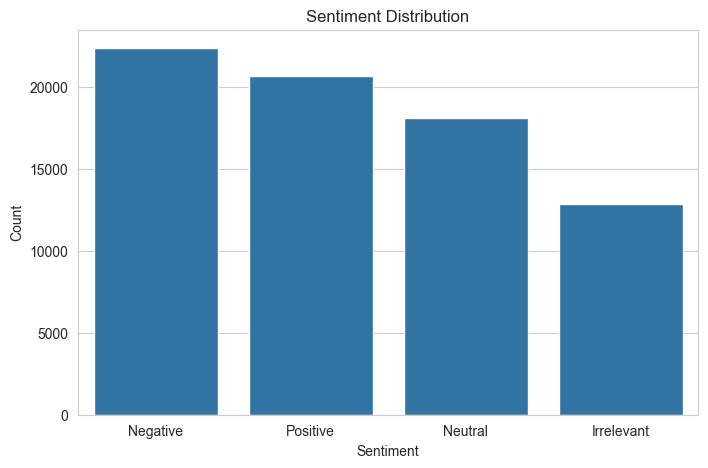

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

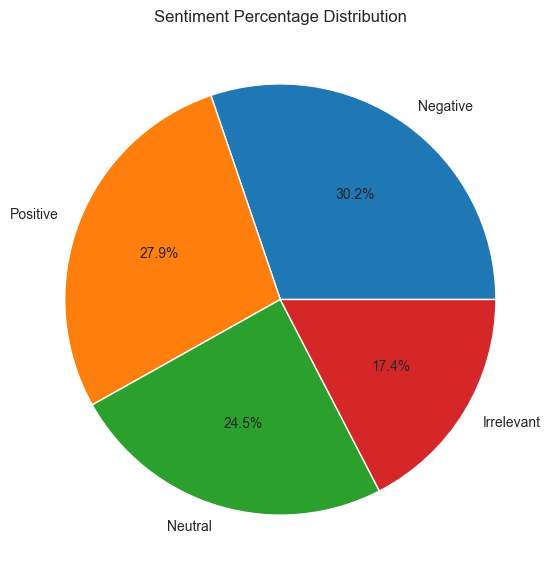

In [9]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Sentiment Percentage Distribution")
plt.ylabel("")

plt.show()

In [10]:
top_entities = df["Entity"].value_counts().head(10)

top_entities

Entity
LeagueOfLegends         2377
MaddenNFL               2377
CallOfDuty              2376
Verizon                 2365
TomClancysRainbowSix    2364
Facebook                2362
Microsoft               2361
Dota2                   2359
WorldOfCraft            2357
ApexLegends             2353
Name: count, dtype: int64

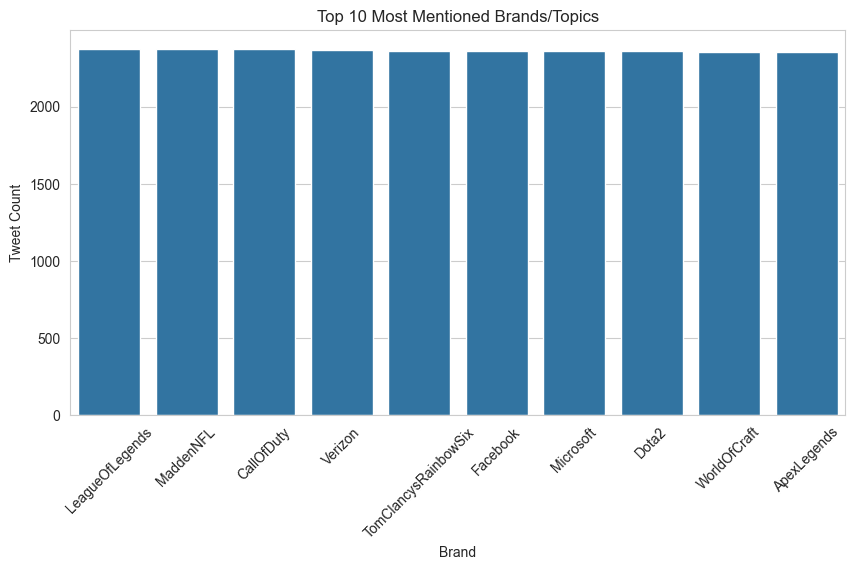

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_entities.index,
    y=top_entities.values
)

plt.title("Top 10 Most Mentioned Brands/Topics")
plt.xlabel("Brand")
plt.ylabel("Tweet Count")

plt.xticks(rotation=45)

plt.show()

In [12]:
top5 = df["Entity"].value_counts().head(5).index

filtered = df[df["Entity"].isin(top5)]

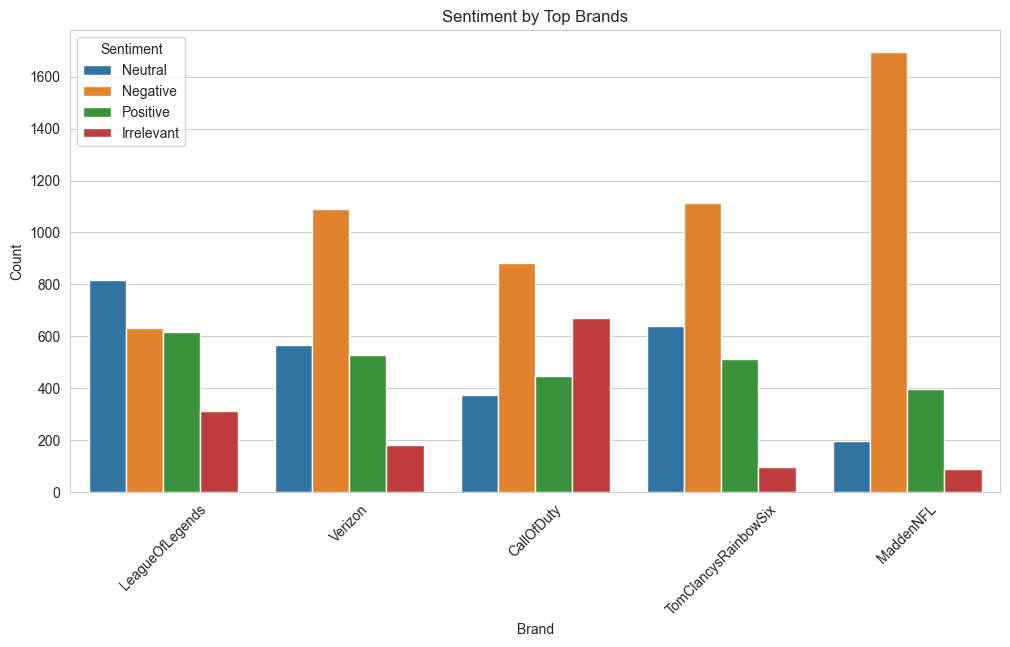

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered,
    x="Entity",
    hue="Sentiment"
)

plt.title("Sentiment by Top Brands")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()